In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


In [14]:
results_folders = ["qaoa_results_11_by_qubit_counts", "qaoa_results_12_by_qubit_counts"]
result_paths = []
for results_folder in results_folders:
    paths = list(pathlib.Path(f"qaoa/{results_folder}").glob("*.npz"))
    result_paths.extend(paths)

result_files = {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in result_paths}
result_files

{'5PTI_9_11_3_8_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_9_11_3_8_layers.npz')},
 '5PTI_20_25_3_12_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_20_25_3_12_layers.npz')},
 '5PTI_11_13_3_4_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_11_13_3_4_layers.npz')},
 '5PTI_22_28_3_12_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_22_28_3_12_layers.npz')},
 '5PTI_22_28_3_8_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_22_28_3_8_layers.npz')},
 '5PTI_11_16_5_6_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_11_16_5_6_layers.npz')},
 '5PTI_19_22_3_6_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_19_22_3_6_layers.npz')},
 '5PTI_5_9_5_4_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_5_9_5_4_layers.npz')},
 '5PTI_10_14_6_2_layers': {'path': PosixPath('qaoa/qaoa_results_11_by_qubit_counts/5PTI_10_14_6_2_

In [15]:
data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]
names_set = set()

for name, data in result_files.items():
    with open(data["path"], 'rb') as f:
        saved_results = np.load(f, allow_pickle=True)
        result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

    result_files[name]["protein"] = name.split("_")[0]
    result_files[name]["start_residue"] = int(name.split("_")[1])
    result_files[name]["end_residue"] = int(name.split("_")[2])
    result_files[name]["rotamer_count"] = int(name.split("_")[3])
    result_files[name]["qaoa_layers"] = int(name.split("_")[4])

    result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
    result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

    name_without_layers = "_".join(name.split("_")[:-2])
    names_set.add(name_without_layers)

In [480]:
names_set

{'5PTI_18_22_4',
 '5PTI_18_22_5',
 '5PTI_18_23_4',
 '5PTI_19_23_4',
 '5PTI_19_23_5',
 '5PTI_20_24_4',
 '5PTI_20_25_4',
 '5PTI_21_25_4',
 '5PTI_21_25_5',
 '5PTI_22_26_4',
 '5PTI_22_26_5',
 '5PTI_22_27_4',
 '5PTI_22_27_5',
 '5PTI_22_28_4',
 '5PTI_22_28_5'}

In [16]:
energy_files = list(pathlib.Path("extraction/alt_energies").rglob("*.pkl"))
file_to_qubit_count_mapping = {}
for file in energy_files:
    file_stem = str(file.stem)
    str_qubit_count = file.as_posix().split("/")[-2]
    try:
        qubit_count = int(str_qubit_count)
        file_to_qubit_count_mapping[file_stem] = qubit_count
    except ValueError:
        print(f"Warning: Could not convert '{str_qubit_count}' to an integer for file {file_stem}. Skipping this file.")

In [17]:
# Attach number of qubits to each result record
for name, data in result_files.items():
    name_without_layers = "_".join(name.split("_")[:-2])
    if name_without_layers in file_to_qubit_count_mapping:
        result_files[name]["num_qubits"] = file_to_qubit_count_mapping[name_without_layers]
    else:
        print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
        result_files[name]["num_qubits"] = None

In [18]:
target_probs_records = []

for name, data in result_files.items():
    # if not name.startswith("5PTI_18_22"): continue

    target_probs = result_files[name]["data"]['target_probs']
    print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

    # Sum across the 16 conformations for each seed
    summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
    print("Shape after summing across conformations:", summed_probs.shape)

    # Create a record for each seed with its summed probability
    for seed_idx, summed_prob in enumerate(summed_probs):
        record = {
            'protein': result_files[name]['protein'],
            'subsection': result_files[name]['subsection'],
            'subsection_length': result_files[name]['subsection_length'],
            'rotamer_count': result_files[name]['rotamer_count'],
            'qaoa_layers': result_files[name]['qaoa_layers'],
            'num_qubits': result_files[name]['num_qubits'],
            'seed': seed_idx,
            'target_prob': summed_prob  # This is now the sum across all 16 conformations
        }
        target_probs_records.append(record)

# Create dataframe from records
target_probs_df = pd.DataFrame(target_probs_records)

Shape of target_probs: (30, 8)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 3)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 11)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 11)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 12)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 2)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 5)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 10)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 17)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 11)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 3)
Shape after s

In [7]:
target_probs_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob
0,5PTI,9-11,3,3,8,6,0,0.999999
1,5PTI,9-11,3,3,8,6,1,1.000000
2,5PTI,9-11,3,3,8,6,2,0.999887
3,5PTI,9-11,3,3,8,6,3,1.000000
4,5PTI,9-11,3,3,8,6,4,0.999798
...,...,...,...,...,...,...,...,...
7495,5PTI,22-28,7,3,6,9,25,0.997517
7496,5PTI,22-28,7,3,6,9,26,0.840509
7497,5PTI,22-28,7,3,6,9,27,0.997313
7498,5PTI,22-28,7,3,6,9,28,0.977222


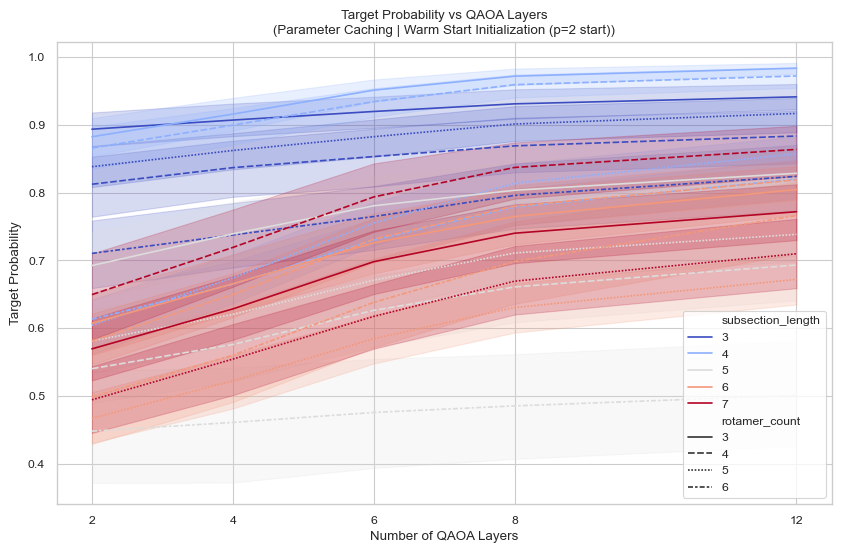

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap=True, n_colors=target_probs_df['subsection_length'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/{results_folder}_2.svg", dpi=300, bbox_inches='tight')

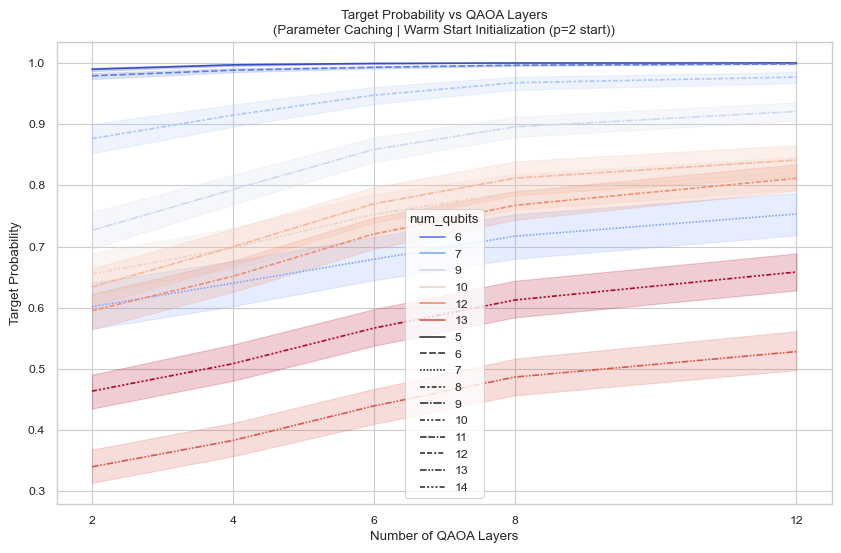

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap=True,
                                       n_colors=target_probs_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/{results_folder}_2.svg", dpi=300, bbox_inches='tight')

In [21]:
# Calculate number of shots needed for 99% confidence
target_confidence = 0.9999
target_probs_df['shots_for_99_percent'] = np.ceil(np.log(1 - target_confidence) / np.log(1 - target_probs_df['target_prob']))

# Replace any infinities (when target_prob is very close to 1) with a large number
target_probs_df['shots_for_99_percent'] = target_probs_df['shots_for_99_percent'].replace([np.inf, -np.inf], 1e6)
target_probs_df['shots_for_99_percent'] = target_probs_df['shots_for_99_percent'].replace([np.NaN], 1)

target_probs_df.head()


/Users/stwrt/Documents/uni/Dissertation/qml_protein_folding/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/stwrt/Documents/uni/Dissertation/qml_protein_folding/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_99_percent
0,5PTI,9-11,3,3,8,6,0,0.999999,1.0
1,5PTI,9-11,3,3,8,6,1,1.000000,1.0
2,5PTI,9-11,3,3,8,6,2,0.999887,2.0
3,5PTI,9-11,3,3,8,6,3,1.000000,1.0
4,5PTI,9-11,3,3,8,6,4,0.999798,2.0


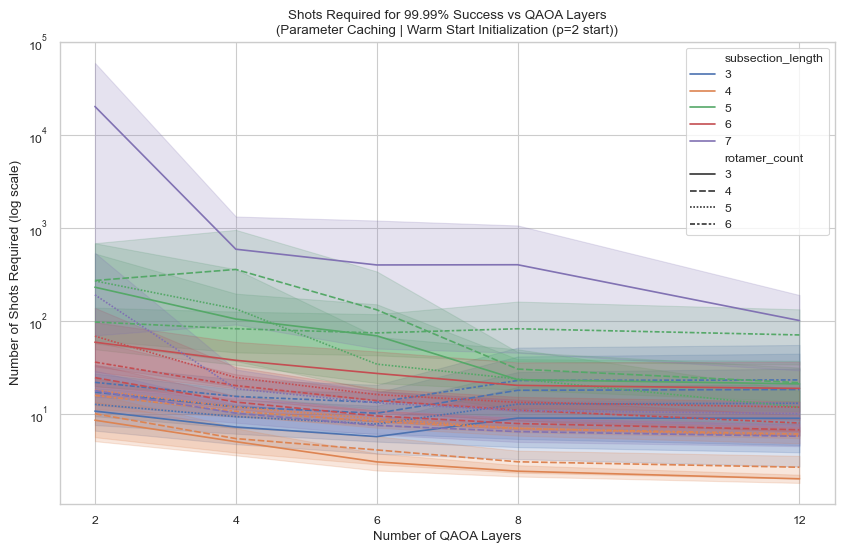

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('deep', n_colors=target_probs_df['subsection_length'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude

ax.set_title(f"Shots Required for {target_confidence*100:.2f}% Success vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Number of Shots Required (log scale)")

plt.savefig(f"plots/{results_folder}_shots.svg", dpi=300, bbox_inches='tight')

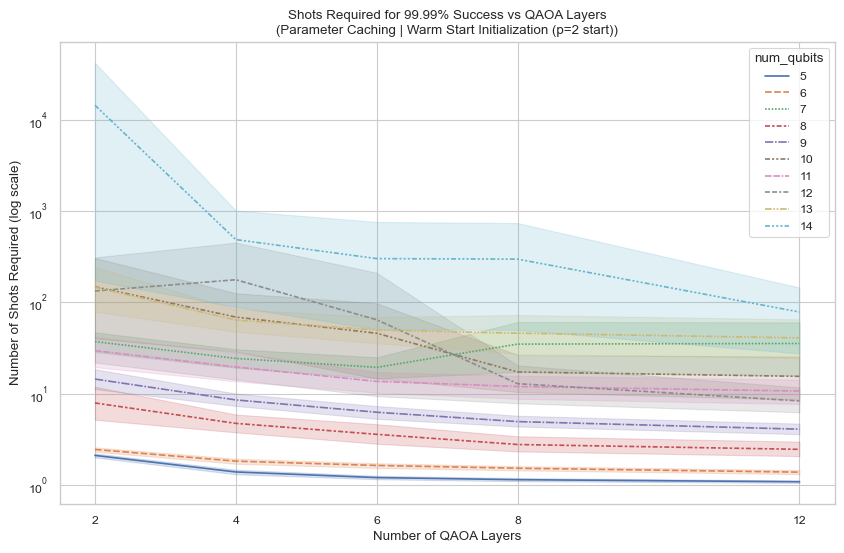

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', n_colors=target_probs_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude

ax.set_title(f"Shots Required for {target_confidence*100:.2f}% Success vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Number of Shots Required (log scale)")

plt.savefig(f"plots/{results_folder}_shots.svg", dpi=300, bbox_inches='tight')

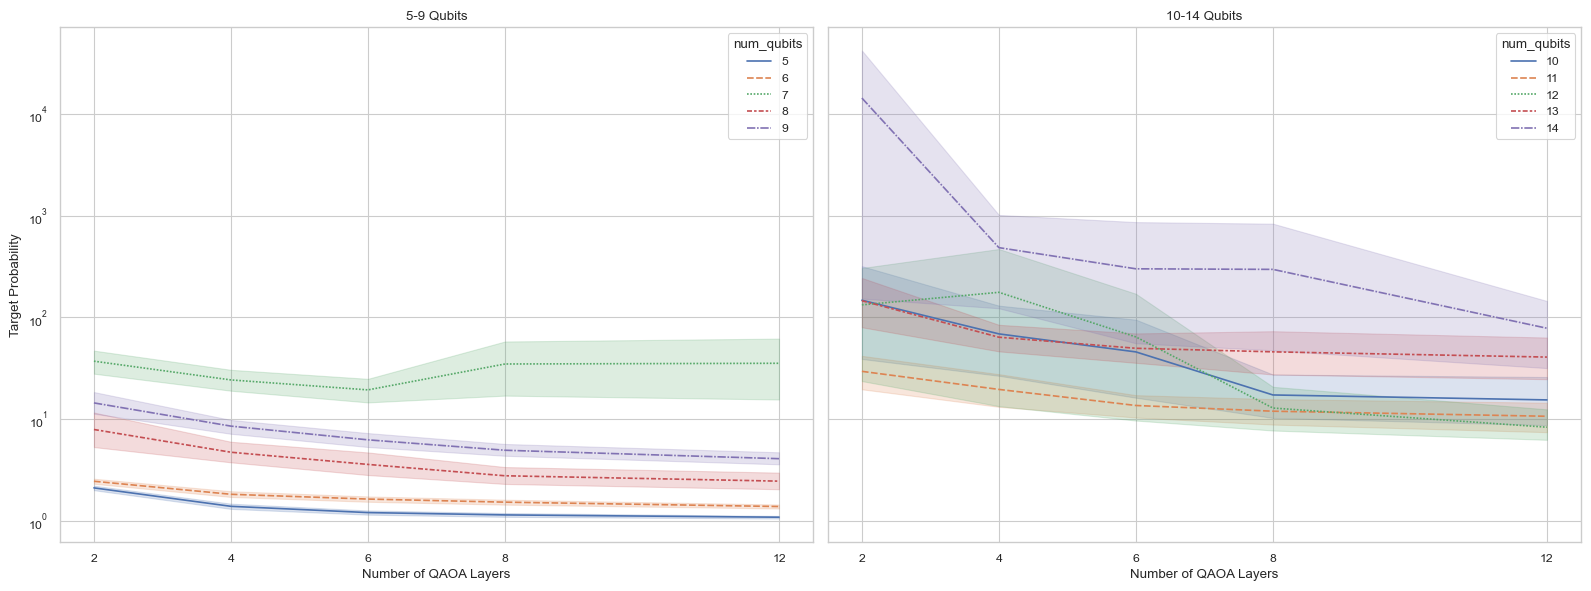

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Filter data for 5-9 qubits
data_5_9 = target_probs_df[(target_probs_df['num_qubits'] >= 5) & (target_probs_df['num_qubits'] <= 9)]

# Filter data for 10-14 qubits
data_10_14 = target_probs_df[(target_probs_df['num_qubits'] >= 10) & (target_probs_df['num_qubits'] <= 14)]

# Plot 1: 5-9 qubits
sns.lineplot(data=data_5_9,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_5_9['num_qubits'].nunique()),
             ax=ax1)
ax1.set_xticks([2, 4, 6, 8, 12])
ax1.set_title("5-9 Qubits")
ax1.set_ylabel("Number of Shots Required (log scale)")
ax1.set_xlabel("Number of QAOA Layers")

# Plot 2: 10-14 qubits
sns.lineplot(data=data_10_14,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_10_14['num_qubits'].nunique()),
             ax=ax2)
ax2.set_xticks([2, 4, 6, 8, 12])
ax2.set_title("10-14 Qubits")
ax2.set_ylabel("Number of Shots Required (log scale)")
ax2.set_xlabel("Number of QAOA Layers")

# Share the same y-axis limits if desired
ax1.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude
ax2.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude


plt.tight_layout()
plt.savefig(f"plots/{results_folder}_split.svg", dpi=300, bbox_inches='tight')

/var/folders/01/t57whxgn07b0dg1mhrwgv0kw0000gn/T/ipykernel_39710/1367762863.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=data_last_layer,


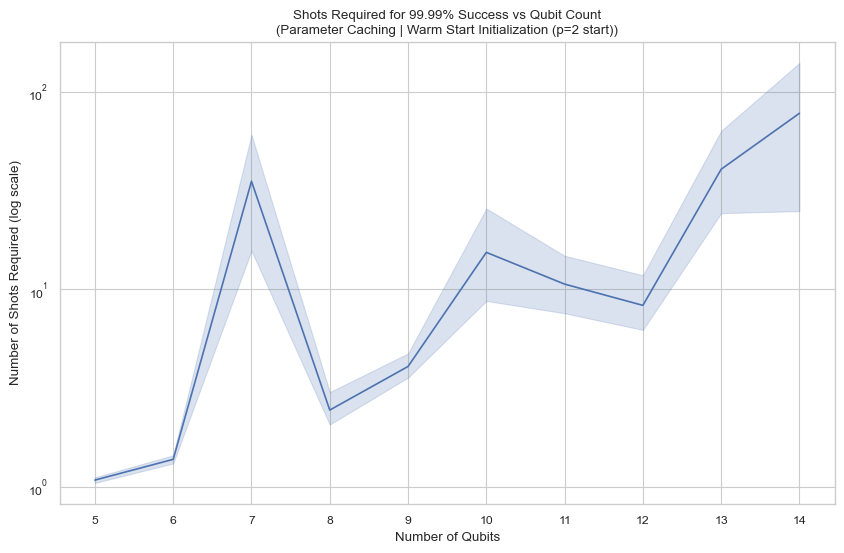

In [34]:
data_last_layer = target_probs_df[(target_probs_df['qaoa_layers'] == 12) ]

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=data_last_layer,
             x="num_qubits", y="shots_for_99_percent",
             # hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep'),
             ax=ax)

ax.set_xticks(list(range(5, 15)))
ax.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude

ax.set_title(
    f"Shots Required for {target_confidence * 100:.2f}% Success vs Qubit Count\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of Qubits")
ax.set_ylabel("Number of Shots Required (log scale)")

plt.savefig(f"plots/{results_folder}_last_layer_shot_scaling.svg", dpi=300, bbox_inches='tight')

In [35]:
runtimes = pd.read_pickle("qaoa_runtimes2.pkl")
runtimes

,Qubits,Total Layers,Time (s)
0,5,32,227.97
1,5,32,231.10
2,5,32,227.01
3,5,32,234.55
4,5,32,134.32
...,...,...,...
95,14,32,3361.12
96,14,32,3256.56
97,14,32,2529.83
98,14,32,3232.14


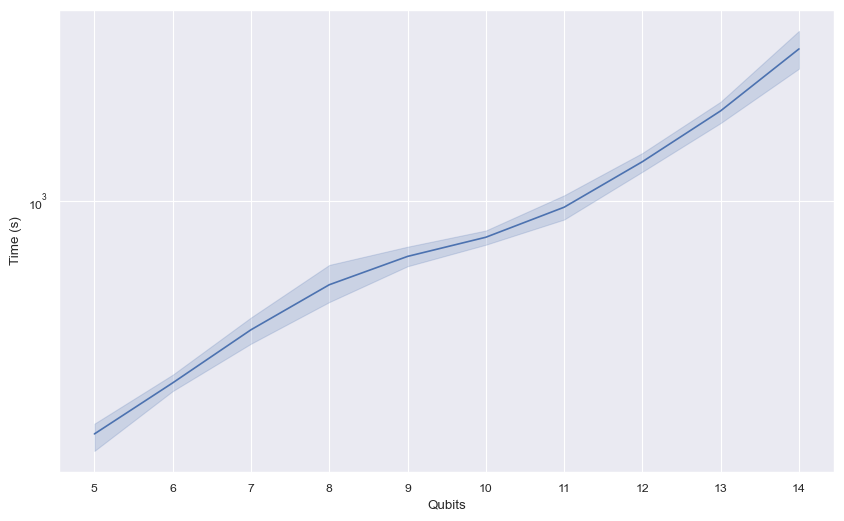

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = runtimes['Qubits'].unique()
x_axis_vals.sort()

sns.lineplot(runtimes, x="Qubits", y="Time (s)",
             markers=False,
             # hue='blue',
             ax=ax)
ax.set_xticks(x_axis_vals)
ax.set_yscale('log')

plt.savefig(f"plots/runtimes.svg", dpi=300, bbox_inches='tight')